1. Problem statement

This project understands how student performance (tes scores) is affected by other variables such as gender, ethnicity, parental eduacation, lunch and test preparation course

2. Data collection 

dataset source - kaggle
the data consistes of 8 column and 1000 rows

2.1 Import data and required packages

Pandas
Numpy
Matplotlib
Seaborn
Warnings



In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Import csv as pandas dataframe
df = pd.read_csv('StudentsPerformance.csv')

#Check the first 5 rows of the dataframe
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


3. Dat checks to perform

Check for
a)missing values
b)duplicates
c)data types
d)no of unique values in each column
e)statistics of data
f)various categories present in diff categorical column

In [4]:
# a)missing values
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
# b)duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
# c)data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
# d)statistics of data
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
# e)exploring data (categories)
print("Categories in 'gender' variable: ",end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable: ",end=" ")
print(df['race/ethnicity'].unique())        

print("Categories in 'parental level of education' variable: ",end=" ")
print(df['parental level of education'].unique())   

print("Categories in 'lunch' variable: ",end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ",end=" ")
print(df['test preparation course'].unique())

Categories in 'gender' variable:  ['female' 'male']
Categories in 'race/ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:  ['standard' 'free/reduced']
Categories in 'test preparation course' variable:  ['none' 'completed']


In [9]:
#define numerical and categorical variables
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print("Numerical features: ", numerical_features)
print("Categorical features: ", categorical_features)


Numerical features:  ['math score', 'reading score', 'writing score']
Categorical features:  ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [10]:
#adding total score column and average score column
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average score'] = df['total score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [12]:
reading_score = df[df['reading score']==100]['average score'].count()
writing_score = df[df['writing score']==100]['average score'].count()
math_less_20= df[df['math score']<20]['average score'].count()
print("Number of students with reading score 100: ", reading_score)
print("Number of students with writing score 100: ", writing_score) 
print("Number of students with math score less than 20: ", math_less_20)

Number of students with reading score 100:  17
Number of students with writing score 100:  14
Number of students with math score less than 20:  4


In [13]:
math_less_20= df[df['math score']<=20]['average score'].count()
reading_less_20= df[df['reading score']<20]['average score'].count()
writing_less_20 = df[df['writing score']<=20]['average score'].count()

print(f'Number of students with math score less than or equal to 20: {math_less_20}')
print(f'Number of students with reading score less than 20: {reading_less_20}')
print(f'Number of students with writing score less than or equal to 20: {writing_less_20}') 

Number of students with math score less than or equal to 20: 4
Number of students with reading score less than 20: 1
Number of students with writing score less than or equal to 20: 3


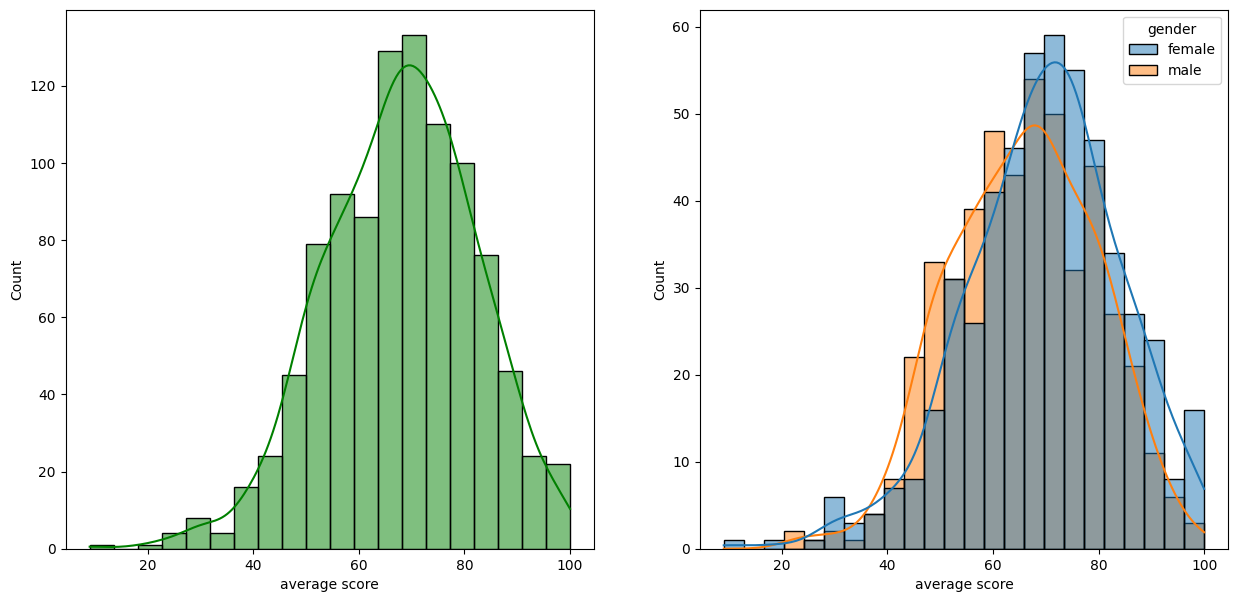

In [25]:
# Histogram and KDE

fig, ax = plt.subplots( 1,2,figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average score', bins=20, kde=True, color='green')
plt.subplot(122)
sns.histplot(data=df,x='average score', kde=True, hue='gender')    
plt.show()

Insights:
Female students tend to perform well than male students

In [ ]:
plt.subplots(1,3,figsize=(15, 7))
plt.subplot(131)
sns.histplot(data=df,x='math score', bins=20, kde=True, color='blue',hue ='lunch')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='reading score', bins=20, kde=True, color='red')